In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
datos_experimentales = np.load('conversion_datos_Exp.npz')

alpha = datos_experimentales['alpha']
delta = datos_experimentales['delta']
tiempos_dias_jd = datos_experimentales['tiempos_dias_jd']



1ra Interpolación: Desde el 9 de Febrero hasta el 11 de Marzo

In [3]:
alpha_1 = alpha[0:4]
delta_1 = delta[0:4]

tiempos_uso_jd_1 = tiempos_dias_jd[0:4]  
tiempos_uso_jd_1

array([2461081.49722222, 2461100.50972222, 2461102.47638889,
       2461111.50138889])

In [4]:
tiempo_central_1 = np.mean(tiempos_uso_jd_1)
print("Tiempo central (JD):", tiempo_central_1)

Tiempo central (JD): 2461098.9961805553


In [5]:
#Construcción del vector rho

rho = np.zeros((4, 3))

for i in range(4):
    rho[i, 0] = np.cos(delta_1[i]) * np.cos(alpha_1[i])  # x
    rho[i, 1] = np.cos(delta_1[i]) * np.sin(alpha_1[i])  # y
    rho[i, 2] = np.sin(delta_1[i])                     # z

In [6]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo = tiempos_uso_jd_1 - tiempos_uso_jd_1[0]

poly_lambda = np.polyfit(tiempo_relativo, rho[:, 0], 2)
poly_mu = np.polyfit(tiempo_relativo, rho[:, 1], 2)
poly_nu = np.polyfit(tiempo_relativo, rho[:, 2], 2)

tiempo_central_reescalado = tiempo_central_1 - tiempos_uso_jd_1[0] 

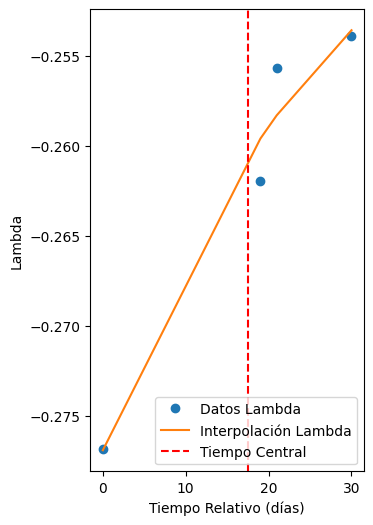

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo, rho[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo, np.polyval(poly_lambda, tiempo_relativo), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [8]:
#Para lambda

l_val = np.polyval(poly_lambda, tiempo_central_reescalado)

derivada_1_l = np.polyder(poly_lambda,1)
l_dval = np.polyval(derivada_1_l, tiempo_central_reescalado)

derivada_2_l = np.polyder(poly_lambda,2)
l_ddval = np.polyval(derivada_2_l, tiempo_central_reescalado)

#Para mu

mu_val = np.polyval(poly_mu, tiempo_central_reescalado)

derivada_1_mu = np.polyder(poly_mu,1)
mu_dval = np.polyval(derivada_1_mu, tiempo_central_reescalado)

derivada_2_mu = np.polyder(poly_mu,2)
mu_ddval = np.polyval(derivada_2_mu, tiempo_central_reescalado)

#Para nu

nu_val = np.polyval(poly_nu, tiempo_central_reescalado)

derivada_1_nu = np.polyder(poly_nu,1)
nu_dval = np.polyval(derivada_1_nu, tiempo_central_reescalado)

derivada_2_nu = np.polyder(poly_nu,2)
nu_ddval = np.polyval(derivada_2_nu, tiempo_central_reescalado)

In [70]:
#l_val, mu_val y nu_val están dentro del rango de -1 a 1.
#l_dval está en el rango de 10e-3, y mu_dval y nu_dval están en el rango de 10e-4.
#l_ddval, mu_ddval y nu_ddval están en el rango de 10e-5. Esto es consistente con lo que se espera para las posiciones y velocidades de un planeta en el sistema solar.

In [9]:
#Datos de las efemérides del Sol

X = -0.92166819869956
Y = 0.3624168676580381
Z = -1.877615350367358e-5


#Distancia desde el Sol hasta el planeta Tierra (aproximadamente 1UA)
R = np.sqrt(X**2 + Y**2 + Z**2)

In [11]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D = np.array([
    [l_val,  l_dval,  l_ddval],
    [mu_val, mu_dval, mu_ddval],
    [nu_val, nu_dval, nu_ddval]
])

# Calcular el determinante D
D = np.linalg.det(matriz_D)
print("Determinante D:", D)

#D está dando 4.5923456027e-08. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1 = np.array([
    [l_val, l_dval, X],
    [mu_val, mu_dval, Y],
    [nu_val, nu_dval, Z]
])

#Calcular el determiante D1
D1 = k2* np.linalg.det(matriz_D1)
print("Determinante D1:", D1)

Determinante D: 9.617489848395426e-09
Determinante D1: 4.438547931492719e-08


In [12]:
#Intento preliminar
intento = D1/D * (1/(0.99)**3 - 1/(5.2)**3)
intento

np.float64(4.72352537608512)

In [13]:
cos_phi = (l_val*X + mu_val*Y +nu_val*Z)/(R)

# Bucle para hallar r y rho

r_obj = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new = (D1 / D) * (1/R**3 - 1/r_obj**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj = np.sqrt(rho_new**2 + R**2 + 2 * rho_new * R * cos_phi)
    
    print(f"{i:<5} | {rho_new:<15.8f} | {r_obj:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new - rho_old) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old = rho_new
    i += 1

rho_final = rho_new
r_final = r_obj

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 4.71830171      | 5.34125438     
1     | 4.72083750      | 5.34376036     
2     | 4.72088009      | 5.34380245     
3     | 4.72088080      | 5.34380316     
4     | 4.72088082      | 5.34380317     
5     | 4.72088082      | 5.34380317     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 4.720881 UA
Distancia Sol-Júpiter (r): 5.343803 UA


In [14]:
#Finalmente, el vectoor de jupiter es

x_jup = X + rho_final * l_val
y_jup = Y + rho_final * mu_val
z_jup = Z + rho_final * nu_val

vector_r_jupiter = np.array([x_jup, y_jup, z_jup])
vector_r_jupiter

array([-2.15220284,  4.52954961,  1.8457969 ])

In [15]:
np.linalg.norm(vector_r_jupiter)

np.float64(5.343759250501187)

2da Interpolación: Desde el 28 de Febrero hasta el 19 de Marzo

In [16]:
tiempos_uso_jd_2 = tiempos_dias_jd[1:5]  
tiempos_uso_jd_2

array([2461100.50972222, 2461102.47638889, 2461111.50138889,
       2461119.54305556])

In [17]:
tiempo_central_2 = np.mean(tiempos_uso_jd_2)
tiempo_central_2

np.float64(2461108.507638889)

In [18]:
#Construcción del vector rho

alpha_2 = alpha[1:5]
delta_2 = delta[1:5]

rho_2 = np.zeros((4, 3))

for i in range(4):
    rho_2[i, 0] = np.cos(delta_2[i]) * np.cos(alpha_2[i])  # x
    rho_2[i, 1] = np.cos(delta_2[i]) * np.sin(alpha_2[i])  # y
    rho_2[i, 2] = np.sin(delta_2[i])                     # z

In [21]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c: Revisar

tiempo_relativo_2 = tiempos_uso_jd_2 - tiempos_uso_jd_2[0]

poly_lambda_2 = np.polyfit(tiempo_relativo_2, rho_2[:, 0], 2)
poly_mu_2 = np.polyfit(tiempo_relativo_2, rho_2[:, 1], 2)
poly_nu_2 = np.polyfit(tiempo_relativo_2, rho_2[:, 2], 2)

tiempo_central_reescalado_2 = tiempo_central_2 - tiempos_uso_jd_2[0] 

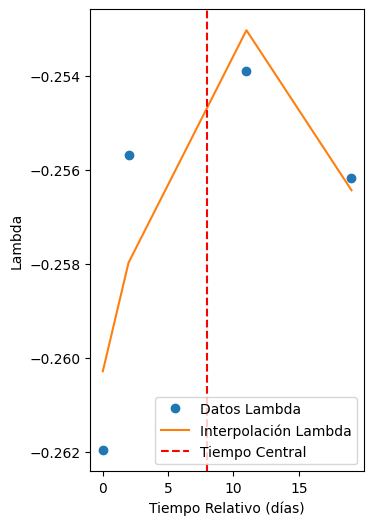

In [22]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_2, rho_2[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_2, np.polyval(poly_lambda_2, tiempo_relativo_2), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_2, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [23]:
#Para lambda

l_val_2 = np.polyval(poly_lambda_2, tiempo_central_reescalado_2)

derivada_1_l_2 = np.polyder(poly_lambda_2,1)
l_dval_2 = np.polyval(derivada_1_l_2, tiempo_central_reescalado_2)

derivada_2_l_2 = np.polyder(poly_lambda_2,2)
l_ddval_2 = np.polyval(derivada_2_l_2, tiempo_central_reescalado_2)

#Para mu

mu_val_2 = np.polyval(poly_mu_2, tiempo_central_reescalado_2)

derivada_1_mu_2 = np.polyder(poly_mu_2,1)
mu_dval_2 = np.polyval(derivada_1_mu_2, tiempo_central_reescalado_2)

derivada_2_mu_2 = np.polyder(poly_mu_2,2)
mu_ddval_2 = np.polyval(derivada_2_mu_2, tiempo_central_reescalado_2)

#Para nu

nu_val_2 = np.polyval(poly_nu_2, tiempo_central_reescalado_2)

derivada_1_nu_2 = np.polyder(poly_nu_2,1)
nu_dval_2 = np.polyval(derivada_1_nu_2, tiempo_central_reescalado_2)

derivada_2_nu_2 = np.polyder(poly_nu_2,2)
nu_ddval_2 = np.polyval(derivada_2_nu_2, tiempo_central_reescalado_2)

In [24]:
X_2 = -0.9712751310029790
Y_2 = 0.2052987725362495
Z_2 = -4.038939877607600e-06

R_2 = np.sqrt(X_2**2 + Y_2**2 + Z_2**2)
R_2


np.float64(0.992735093630752)

In [29]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_2 = np.array([
    [l_val_2,  l_dval_2,  l_ddval_2],
    [mu_val_2, mu_dval_2, mu_ddval_2],
    [nu_val_2, nu_dval_2, nu_ddval_2]
])

# Calcular el determinante D
D_2 = np.linalg.det(matriz_D_2)
print(D_2)

#D está dando 6.040795640314e-08. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_2 = np.array([
    [l_val_2, l_dval_2, X_2],
    [mu_val_2, mu_dval_2, Y_2],
    [nu_val_2, nu_dval_2, Z_2]
])

#Calcular el determiante D1
D1_2 = -k2* np.linalg.det(matriz_D1_2)
print(D1_2)

-3.6824741437939543e-09
-2.5358369446372463e-08


In [32]:
#Intento preliminar
intento_2 = D1_2/(D_2) * (1/(0.99)**3 - 1/(5.2)**3)
intento_2

np.float64(7.048045415823608)

In [33]:
cos_phi_2 = (l_val_2*X_2 + mu_val_2*Y_2 +nu_val_2*Z_2)/(R_2)

# Bucle para hallar r y rho

r_obj_2 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_2 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_2 = (D1_2 / D_2) * (1/R_2**3 - 1/r_obj_2**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_2 = np.sqrt(rho_new_2**2 + R_2**2 + 2 * rho_new_2 * R_2 * cos_phi_2)
    
    print(f"{i:<5} | {rho_new_2:<15.8f} | {r_obj_2:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_2 - rho_old_2) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_2 = rho_new_2
    i += 1

rho_final_2 = rho_new_2
r_final_2 = r_obj_2

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_2:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_2:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 6.98954768      | 7.47147458     
1     | 7.02201177      | 7.50370554     
2     | 7.02222361      | 7.50391587     
3     | 7.02222498      | 7.50391723     
4     | 7.02222499      | 7.50391724     
----------------------------------------
¡Convergencia lograda en 4 iteraciones!

Distancia Tierra-Júpiter (rho): 7.022225 UA
Distancia Sol-Júpiter (r): 7.503917 UA


In [34]:
#Finalmente, el vectoor de jupiter es

x_jup_2 = X_2 + rho_final_2 * l_val_2
y_jup_2 = Y_2 + rho_final_2 * mu_val_2
z_jup_2 = Z_2 + rho_final_2 * nu_val_2

vector_r_jupiter_2 = np.array([x_jup_2, y_jup_2, z_jup_2])
vector_r_jupiter_2

array([-2.75245225,  6.4196643 ,  2.74242278])

In [35]:
np.linalg.norm(vector_r_jupiter_2)

np.float64(7.503930021975989)

3ra Interpolación: desde el 9 de Febrero hasta el 11 de Marzo


In [44]:
tiempos_uso_jd_3 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_3)

tiempo_central_3 = np.mean(tiempos_uso_jd_3)
print(tiempo_central_3)

#Construcción del vector rho

alpha_3 = [alpha[0],alpha[1],alpha[3],alpha[5]]
delta_3 = [delta[0],delta[1],delta[3],delta[5]]

rho_3 = np.zeros((4, 3))

for i in range(4):
    rho_3[i, 0] = np.cos(delta_3[i]) * np.cos(alpha_3[i])  # x
    rho_3[i, 1] = np.cos(delta_3[i]) * np.sin(alpha_3[i])  # y
    rho_3[i, 2] = np.sin(delta_3[i])                     # z


[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461105.003125


In [ ]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_3 = tiempos_uso_jd_3 - tiempos_uso_jd_3[0]

poly_lambda_3 = np.polyfit(tiempo_relativo_3, rho_3[:, 0], 2)
poly_mu_3 = np.polyfit(tiempo_relativo_3, rho_3[:, 1], 2)
poly_nu_3 = np.polyfit(tiempo_relativo_3, rho_3[:, 2], 2)

tiempo_central_reescalado_3 = tiempo_central_3 - tiempos_uso_jd_3[0] 

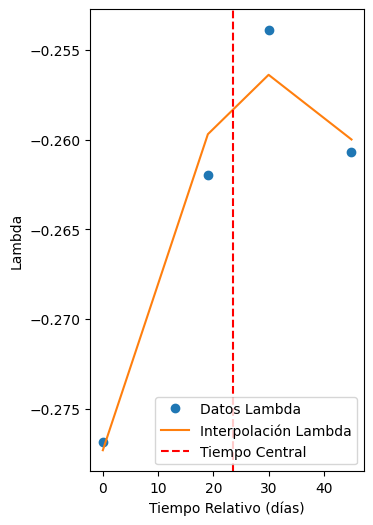

In [46]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_3, rho_3[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_3, np.polyval(poly_lambda_3, tiempo_relativo_3), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_3, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [47]:
#Para lambda

l_val_3 = np.polyval(poly_lambda_3, tiempo_central_reescalado_3)

derivada_1_l_3 = np.polyder(poly_lambda_3,1)
l_dval_3 = np.polyval(derivada_1_l_3, tiempo_central_reescalado_3)

derivada_2_l_3 = np.polyder(poly_lambda_3,2)
l_ddval_3 = np.polyval(derivada_2_l_3, tiempo_central_reescalado_3)

#Para mu

mu_val_3 = np.polyval(poly_mu_3, tiempo_central_reescalado_3)

derivada_1_mu_3 = np.polyder(poly_mu_3,1)
mu_dval_3 = np.polyval(derivada_1_mu_3, tiempo_central_reescalado_3)

derivada_2_mu_3 = np.polyder(poly_mu_3,2)
mu_ddval_3 = np.polyval(derivada_2_mu_3, tiempo_central_reescalado_3)

#Para nu

nu_val_3 = np.polyval(poly_nu_3, tiempo_central_reescalado_3)

derivada_1_nu_3 = np.polyder(poly_nu_3,1)
nu_dval_3 = np.polyval(derivada_1_nu_3, tiempo_central_reescalado_3)

derivada_2_nu_3 = np.polyder(poly_nu_3,2)
nu_ddval_3 = np.polyval(derivada_2_nu_3, tiempo_central_reescalado_3)

In [48]:
X_3= -9.560206927483522e-01
Y_3 = 2.640757619855256e-01
Z_3 = -9.056560159715226e-06

R_3 = np.sqrt(X_3**2 + Y_3**2 + Z_3**2)
print(R_3)

0.9918223495733984


In [50]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_3 = np.array([
    [l_val_3,  l_dval_3,  l_ddval_3],
    [mu_val_3, mu_dval_3, mu_ddval_3],
    [nu_val_3, nu_dval_3, nu_ddval_3]
])

# Calcular el determinante D
D_3 = np.linalg.det(matriz_D_3)
print(D_3)

#D está dando 6.040795640314e-08. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_3 = np.array([
    [l_val_3, l_dval_3, X_3],
    [mu_val_3, mu_dval_3, Y_3],
    [nu_val_3, nu_dval_3, Z_3]
])

#Calcular el determiante D1
D1_3 = -k2* np.linalg.det(matriz_D1_3)
print(D1_3)

-2.2967235108865333e-09
-4.470321426920241e-09


In [51]:
#Intento preliminar
intento_3 = D1_3/D_3 * (1/(0.99)**3 - 1/(5.2)**3)
intento_3

np.float64(1.9921274060236818)

In [52]:
cos_phi_3 = (l_val_3*X_3 + mu_val_3*Y_3 +nu_val_3*Z_3)/(R_3)

# Bucle para hallar r y rho

r_obj_3 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_3 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_3 = (D1_3 / D_3) * (1/R_3**3 - 1/r_obj_3**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_3 = np.sqrt(rho_new_3**2 + R_3**2 + 2 * rho_new_3 * R_3 * cos_phi_3)
    
    print(f"{i:<5} | {rho_new_3:<15.8f} | {r_obj_3:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_3 - rho_old_3) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_3 = rho_new_3
    i += 1

rho_final_3 = rho_new_3
r_final_3 = r_obj_3

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_3:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_3:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 1.98109055      | 2.60949059     
1     | 1.88539573      | 2.51944673     
2     | 1.87322652      | 2.50802613     
3     | 1.87155632      | 2.50645923     
4     | 1.87132479      | 2.50624203     
5     | 1.87129265      | 2.50621188     
6     | 1.87128819      | 2.50620769     
7     | 1.87128757      | 2.50620711     
8     | 1.87128749      | 2.50620703     
9     | 1.87128747      | 2.50620702     
10    | 1.87128747      | 2.50620702     
----------------------------------------
¡Convergencia lograda en 10 iteraciones!

Distancia Tierra-Júpiter (rho): 1.871287 UA
Distancia Sol-Júpiter (r): 2.506207 UA


In [ ]:
#Finalmente, el vector de jupiter es

x_jup_3 = X_3 + rho_final_3 * l_val_3
y_jup_3 = Y_3 + rho_final_3 * mu_val_3
z_jup_3 = Z_3 + rho_final_3 * nu_val_3

vector_r_jupiter_3 = np.array([x_jup_3, y_jup_3, z_jup_3])
vector_r_jupiter_3

array([-1.43832142,  1.91791841,  0.73065112])

In [54]:
np.linalg.norm(vector_r_jupiter_3)

np.float64(2.506198437546626)

4ta Interpolación: Desde el 9 de Febrero hasta el 11 de marzo


In [ ]:
tiempos_uso_jd_4 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[3]]  
print(tiempos_uso_jd_4)

tiempo_central_4 = np.mean(tiempos_uso_jd_4)
print(tiempo_central_4)

#Construcción del vector rho

alpha_4 = [alpha[0],alpha[1],alpha[3]]
delta_4 = [delta[0],delta[1],delta[3]]

rho_4 = np.zeros((3, 3))

for i in range(3):
    rho_4[i, 0] = np.cos(delta_4[i]) * np.cos(alpha_4[i])  # x
    rho_4[i, 1] = np.cos(delta_4[i]) * np.sin(alpha_4[i])  # y
    rho_4[i, 2] = np.sin(delta_4[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461111.501388889)]
2461097.836111111


In [56]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_4 = tiempos_uso_jd_4 - tiempos_uso_jd_4[0]

poly_lambda_4 = np.polyfit(tiempo_relativo_4, rho_4[:, 0], 2)
poly_mu_4 = np.polyfit(tiempo_relativo_4, rho_4[:, 1], 2)
poly_nu_4 = np.polyfit(tiempo_relativo_4, rho_4[:, 2], 2)

tiempo_central_reescalado_4 = tiempo_central_4 - tiempos_uso_jd_4[0] 

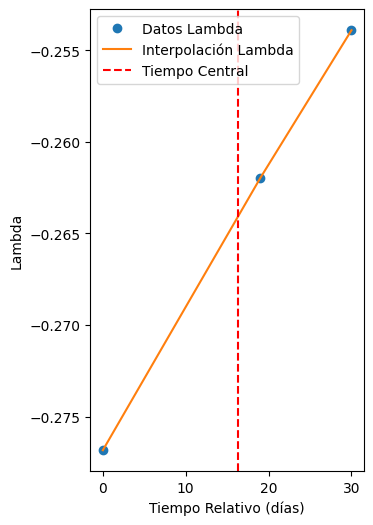

In [58]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_4, rho_4[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_4, np.polyval(poly_lambda_4, tiempo_relativo_4), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_4, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [59]:
#Para lambda

l_val_4 = np.polyval(poly_lambda_4, tiempo_central_reescalado_4)

derivada_1_l_4 = np.polyder(poly_lambda_4,1)
l_dval_4 = np.polyval(derivada_1_l_4, tiempo_central_reescalado_4)

derivada_2_l_4 = np.polyder(poly_lambda_4,2)
l_ddval_4 = np.polyval(derivada_2_l_4, tiempo_central_reescalado_4)

#Para mu

mu_val_4 = np.polyval(poly_mu_4, tiempo_central_reescalado_4)

derivada_1_mu_4 = np.polyder(poly_mu_4,1)
mu_dval_4 = np.polyval(derivada_1_mu_4, tiempo_central_reescalado_4)

derivada_2_mu_4 = np.polyder(poly_mu_4,2)
mu_ddval_4 = np.polyval(derivada_2_mu_4, tiempo_central_reescalado_4)

#Para nu

nu_val_4 = np.polyval(poly_nu_4, tiempo_central_reescalado_4)

derivada_1_nu_4 = np.polyder(poly_nu_4,1)
nu_dval_4 = np.polyval(derivada_1_nu_4, tiempo_central_reescalado_4)

derivada_2_nu_4 = np.polyder(poly_nu_4,2)
nu_ddval_4 = np.polyval(derivada_2_nu_4, tiempo_central_reescalado_4)

In [72]:
X_4= -9.138598924862512e-01
Y_4 = 3.809885458856218e-01
Z_4 = -2.032949553775871e-05

R_4 = np.sqrt(X_4**2 + Y_4**2 + Z_4**2)
print(R_4)

0.9900970536287398


In [73]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_4 = np.array([
    [l_val_4,  l_dval_4,  l_ddval_4],
    [mu_val_4, mu_dval_4, mu_ddval_4],
    [nu_val_4, nu_dval_4, nu_ddval_4]
])

# Calcular el determinante D
D_4 = np.linalg.det(matriz_D_4)
print(D_4)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_4 = np.array([
    [l_val_4, l_dval_4, X_4],
    [mu_val_4, mu_dval_4, Y_4],
    [nu_val_4, nu_dval_4, Z_4]
])

#Calcular el determiante D1
D1_4 = k2* np.linalg.det(matriz_D1_4)
print(D1_4)

7.857353753665259e-09
4.4571755886877895e-08


In [74]:
#Intento preliminar
intento_4 = D1_4/D_4 * (1/(0.99)**3 - 1/(5.2)**3)
intento_4

np.float64(5.8059128449523305)

In [75]:
cos_phi_4 = (l_val_4*X_4 + mu_val_4*Y_4 +nu_val_4*Z_4)/(R_4)

# Bucle para hallar r y rho

r_obj_4 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_4 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_4 = (D1_4 / D_4) * (1/R_4**3 - 1/r_obj_4**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_4 = np.sqrt(rho_new_4**2 + R_4**2 + 2 * rho_new_4 * R_4 * cos_phi_4)
    
    print(f"{i:<5} | {rho_new_4:<15.8f} | {r_obj_4:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_4 - rho_old_4) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_4 = rho_new_4
    i += 1

rho_final_4 = rho_new_4
r_final_4 = r_obj_4

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_4:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_4:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 5.80419379      | 6.43193699     
1     | 5.82321870      | 6.45081297     
2     | 5.82340530      | 6.45099811     
3     | 5.82340712      | 6.45099992     
4     | 5.82340713      | 6.45099993     
5     | 5.82340713      | 6.45099993     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 5.823407 UA
Distancia Sol-Júpiter (r): 6.451000 UA


In [76]:
#Finalmente, el vectoor de jupiter es

x_jup_4 = X_4 + rho_final_4 * l_val_4
y_jup_4 = Y_4 + rho_final_4 * mu_val_4
z_jup_4 = Z_4 + rho_final_4 * nu_val_4

vector_r_jupiter_4 = np.array([x_jup_4, y_jup_4, z_jup_4])
vector_r_jupiter_4

array([-2.45114894,  5.51683348,  2.27415212])

In [67]:
np.linalg.norm(vector_r_jupiter_4)

np.float64(6.450996097343615)

5ta Interpolación: 9 de febrero, 2 de marzo y 26 de marzo

In [68]:
tiempos_uso_jd_5 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_5)

tiempo_central_5 = np.mean(tiempos_uso_jd_5)
print(tiempo_central_5)

#Construcción del vector rho

alpha_5 = [alpha[0],alpha[2],alpha[5]]
delta_5 = [delta[0],delta[2],delta[5]]

rho_5 = np.zeros((3, 3))

for i in range(3):
    rho_5[i, 0] = np.cos(delta_5[i]) * np.cos(alpha_5[i])  # x
    rho_5[i, 1] = np.cos(delta_5[i]) * np.sin(alpha_5[i])  # y
    rho_5[i, 2] = np.sin(delta_5[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461126.504166667)]
2461103.4925925923


In [69]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_5 = tiempos_uso_jd_5 - tiempos_uso_jd_5[0]

poly_lambda_5 = np.polyfit(tiempo_relativo_5, rho_5[:, 0], 2)
poly_mu_5 = np.polyfit(tiempo_relativo_5, rho_5[:, 1], 2)
poly_nu_5 = np.polyfit(tiempo_relativo_5, rho_5[:, 2], 2)

tiempo_central_reescalado_5 = tiempo_central_5 - tiempos_uso_jd_5[0] 

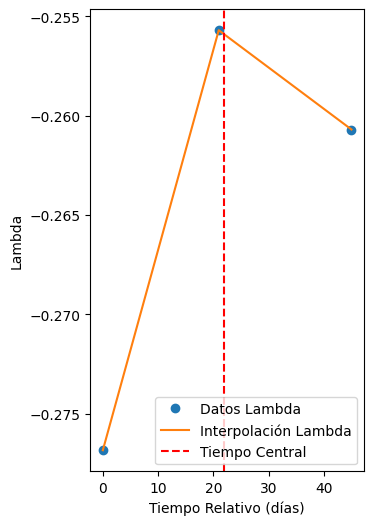

In [70]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_5, rho_5[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_5, np.polyval(poly_lambda_5, tiempo_relativo_5), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_5, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [71]:
#Para lambda

l_val_5 = np.polyval(poly_lambda_5, tiempo_central_reescalado_5)

derivada_1_l_5 = np.polyder(poly_lambda_5,1)
l_dval_5 = np.polyval(derivada_1_l_5, tiempo_central_reescalado_5)

derivada_2_l_5 = np.polyder(poly_lambda_5,2)
l_ddval_5 = np.polyval(derivada_2_l_5, tiempo_central_reescalado_5)

#Para mu

mu_val_5 = np.polyval(poly_mu_5, tiempo_central_reescalado_5)

derivada_1_mu_5 = np.polyder(poly_mu_5,1)
mu_dval_5 = np.polyval(derivada_1_mu_5, tiempo_central_reescalado_5)

derivada_2_mu_5 = np.polyder(poly_mu_5,2)
mu_ddval_5 = np.polyval(derivada_2_mu_5, tiempo_central_reescalado_5)

#Para nu

nu_val_5 = np.polyval(poly_nu_5, tiempo_central_reescalado_5)

derivada_1_nu_5 = np.polyder(poly_nu_5,1)
nu_dval_5 = np.polyval(derivada_1_nu_5, tiempo_central_reescalado_5)

derivada_2_nu_5 = np.polyder(poly_nu_5,2)
nu_ddval_5 = np.polyval(derivada_2_nu_5, tiempo_central_reescalado_5)

In [77]:
X_5= -9.483500860814637e-01
Y_5 = 2.891179792106734e-01
Z_5 = -1.154148494709073e-05

R_5 = np.sqrt(X_5**2 + Y_5**2 + Z_5**2)
print(R_5)

0.9914419255845441


In [79]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_5 = np.array([
    [l_val_5,  l_dval_5,  l_ddval_5],
    [mu_val_5, mu_dval_5, mu_ddval_5],
    [nu_val_5, nu_dval_5, nu_ddval_5]
])

# Calcular el determinante D
D_5 = np.linalg.det(matriz_D_5)
print(D_5)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_5 = np.array([
    [l_val_5, l_dval_5, X_5],
    [mu_val_5, mu_dval_5, Y_5],
    [nu_val_5, nu_dval_5, Z_5]
])

#Calcular el determiante D1
D1_5 = -k2* np.linalg.det(matriz_D1_5)
print(D1_5)

-1.6856680995199179e-09
-5.7689016152615695e-09


In [80]:
#Intento preliminar
intento_5 = D1_5/D_5 * (1/(0.99)**3 - 1/(5.2)**3)
intento_5

np.float64(3.502741917441466)

In [81]:
cos_phi_5 = (l_val_5*X_5 + mu_val_5*Y_5 +nu_val_5*Z_5)/(R_5)

# Bucle para hallar r y rho

r_obj_5 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_5 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_5 = (D1_5 / D_5) * (1/R_5**3 - 1/r_obj_5**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_5 = np.sqrt(rho_new_5**2 + R_5**2 + 2 * rho_new_5 * R_5 * cos_phi_5)
    
    print(f"{i:<5} | {rho_new_5:<15.8f} | {r_obj_5:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_5 - rho_old_5) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_5 = rho_new_5
    i += 1

rho_final_5 = rho_new_5
r_final_5 = r_obj_5

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_5:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_5:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 3.48737522      | 4.07626580     
1     | 3.46118651      | 4.05066683     
2     | 3.46022248      | 4.04972465     
3     | 3.46018653      | 4.04968952     
4     | 3.46018519      | 4.04968820     
5     | 3.46018514      | 4.04968816     
6     | 3.46018514      | 4.04968815     
----------------------------------------
¡Convergencia lograda en 6 iteraciones!

Distancia Tierra-Júpiter (rho): 3.460185 UA
Distancia Sol-Júpiter (r): 4.049688 UA


In [82]:
#Finalmente, el vectoor de jupiter es

x_jup_5 = X_5 + rho_final_5 * l_val_5
y_jup_5 = Y_5 + rho_final_5 * mu_val_5
z_jup_5 = Z_5 + rho_final_5 * nu_val_5

vector_r_jupiter_5 = np.array([x_jup_5, y_jup_5, z_jup_5])
vector_r_jupiter_5

array([-1.83165476,  3.348082  ,  1.35480636])

In [83]:
np.linalg.norm(vector_r_jupiter_5)

np.float64(4.049705240572974)

6ta interpolación:09/02; 02/03;11/03;26/03


In [135]:
tiempos_uso_jd_6 = [tiempos_dias_jd[0],tiempos_dias_jd[2],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_6)

tiempo_central_6 = np.mean(tiempos_uso_jd_6)
print(tiempo_central_6)

#Construcción del vector rho

alpha_6 = [alpha[0],alpha[2],alpha[3],alpha[5]]
delta_6 = [delta[0],delta[2],delta[3],delta[5]]

rho_6 = np.zeros((4, 3))

for i in range(4):
    rho_6[i, 0] = np.cos(delta_6[i]) * np.cos(alpha_6[i])  # x
    rho_6[i, 1] = np.cos(delta_6[i]) * np.sin(alpha_6[i])  # y
    rho_6[i, 2] = np.sin(delta_6[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461102.476388889), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461105.4947916665


In [136]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_6 = tiempos_uso_jd_6 - tiempos_uso_jd_6[0]

poly_lambda_6 = np.polyfit(tiempo_relativo_6, rho_6[:, 0], 2)
poly_mu_6 = np.polyfit(tiempo_relativo_6, rho_6[:, 1], 2)
poly_nu_6 = np.polyfit(tiempo_relativo_6, rho_6[:, 2], 2)

tiempo_central_reescalado_6 = tiempo_central_6 - tiempos_uso_jd_6[0] 

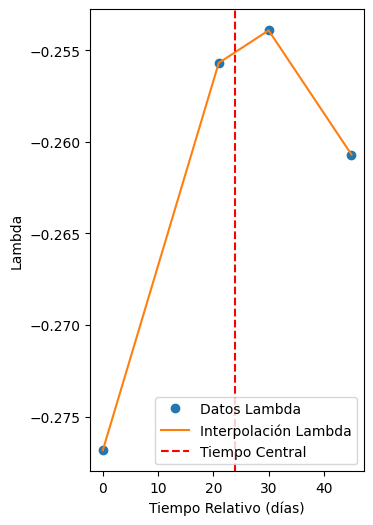

In [138]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_6, rho_6[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_6, np.polyval(poly_lambda_6, tiempo_relativo_6), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_6, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [139]:
#Para lambda

l_val_6 = np.polyval(poly_lambda_6, tiempo_central_reescalado_6)

derivada_1_l_6 = np.polyder(poly_lambda_6,1)
l_dval_6 = np.polyval(derivada_1_l_6, tiempo_central_reescalado_6)

derivada_2_l_6 = np.polyder(poly_lambda_6,2)
l_ddval_6 = np.polyval(derivada_2_l_6, tiempo_central_reescalado_6)

#Para mu

mu_val_6 = np.polyval(poly_mu_6, tiempo_central_reescalado_6)

derivada_1_mu_6 = np.polyder(poly_mu_6,1)
mu_dval_6 = np.polyval(derivada_1_mu_6, tiempo_central_reescalado_6)

derivada_2_mu_6 = np.polyder(poly_mu_6,2)
mu_ddval_6 = np.polyval(derivada_2_mu_6, tiempo_central_reescalado_6)

#Para nu

nu_val_6 = np.polyval(poly_nu_6, tiempo_central_reescalado_6)

derivada_1_nu_6 = np.polyder(poly_nu_6,1)
nu_dval_6 = np.polyval(derivada_1_nu_6, tiempo_central_reescalado_6)

derivada_2_nu_6 = np.polyder(poly_nu_6,2)
nu_ddval_6 = np.polyval(derivada_2_nu_6, tiempo_central_reescalado_6)

In [140]:
X_6= -9.583757011429926e-01
Y_6 = 2.558843792972298e-01
Z_6 = -8.277960093075756e-06

R_6 = np.sqrt(X_6**2 + Y_6**2 + Z_6**2)
print(R_6)

0.9919479825969585


In [144]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_6 = np.array([
    [l_val_6,  l_dval_6,  l_ddval_6],
    [mu_val_6, mu_dval_6, mu_ddval_6],
    [nu_val_6, nu_dval_6, nu_ddval_6]
])

# Calcular el determinante D
D_6 = np.linalg.det(matriz_D_6)
print(D_6)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_6 = np.array([
    [l_val_6, l_dval_6, X_6],
    [mu_val_6, mu_dval_6, Y_6],
    [nu_val_6, nu_dval_6, Z_6]
])

#Calcular el determiante D1
D1_6 = -k2* np.linalg.det(matriz_D1_6)
print(D1_6)

-2.400294398003716e-09
-1.5687381740347877e-09


In [145]:
#Intento preliminar
intento_6 = D1_6/D_6 * (1/(0.99)**3 - 1/(5.2)**3)
intento_6

np.float64(0.6689182249192084)

In [146]:
cos_phi_6 = (l_val_6*X_6 + mu_val_6*Y_6 +nu_val_6*Z_6)/(R_6)

# Bucle para hallar r y rho

r_obj_6 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_6 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_6 = (D1_6 / D_6) * (1/R_6**3 - 1/r_obj_6**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_6 = np.sqrt(rho_new_6**2 + R_6**2 + 2 * rho_new_6 * R_6 * cos_phi_6)
    
    print(f"{i:<5} | {rho_new_6:<15.8f} | {r_obj_6:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_6 - rho_old_6) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_6 = rho_new_6
    i += 1

rho_final_6 = rho_new_6
r_final_6 = r_obj_6

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_6:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_6:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 0.66495777      | 1.43235501     
1     | 0.44720631      | 1.26674050     
2     | 0.34807478      | 1.19688896     
3     | 0.28843091      | 1.15692430     
4     | 0.24754887      | 1.13053308     
5     | 0.21729594      | 1.11156820     
6     | 0.19374762      | 1.09715682     
7     | 0.17474875      | 1.08576252     
8     | 0.15900517      | 1.07648322     
9     | 0.14568687      | 1.06875157     
10    | 0.13423388      | 1.06219132     
11    | 0.12425288      | 1.05654226     
12    | 0.11545843      | 1.05161812     
13    | 0.10763764      | 1.04728174     
14    | 0.10062803      | 1.04342963     
15    | 0.09430311      | 1.03998209     
16    | 0.08856275      | 1.03687666     
17    | 0.08332644      | 1.03406357     
18    | 0.07852863      | 1.03150265     
19    | 0.07411528      | 1.02916106     
20    | 0.07004138      | 1.02701168     
21    | 0.06626909      | 1.0250318

In [147]:
#Finalmente, el vectoor de jupiter es

x_jup_6 = X_6 + rho_final_6 * l_val_6
y_jup_6 = Y_6 + rho_final_6 * mu_val_6
z_jup_6 = Z_6 + rho_final_6 * nu_val_6

vector_r_jupiter_6 = np.array([x_jup_6, y_jup_6, z_jup_6])
vector_r_jupiter_6

array([-0.96287314,  0.27150894,  0.00689661])

In [148]:
np.linalg.norm(vector_r_jupiter_6)

np.float64(1.0004445806186533)

7ta interpolación: 09/02,28/02,11/03,26/03

In [149]:
tiempos_uso_jd_7 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_7)

tiempo_central_7 = np.mean(tiempos_uso_jd_7)
print(tiempo_central_7)

#Construcción del vector rho

alpha_7 = [alpha[0],alpha[1],alpha[3],alpha[5]]
delta_7 = [delta[0],delta[1],delta[3],delta[5]]

rho_7 = np.zeros((4, 3))

for i in range(4):
    rho_7[i, 0] = np.cos(delta_7[i]) * np.cos(alpha_7[i])  # x
    rho_7[i, 1] = np.cos(delta_7[i]) * np.sin(alpha_7[i])  # y
    rho_7[i, 2] = np.sin(delta_7[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461105.003125


In [150]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_7 = tiempos_uso_jd_7 - tiempos_uso_jd_7[0]

poly_lambda_7 = np.polyfit(tiempo_relativo_7, rho_7[:, 0], 2)
poly_mu_7 = np.polyfit(tiempo_relativo_7, rho_7[:, 1], 2)
poly_nu_7 = np.polyfit(tiempo_relativo_7, rho_7[:, 2], 2)

tiempo_central_reescalado_7 = tiempo_central_7 - tiempos_uso_jd_7[0] 

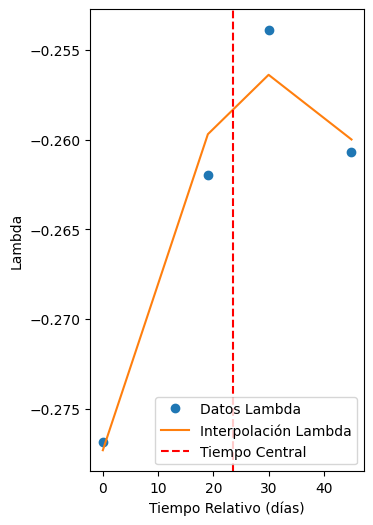

In [151]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_7, rho_7[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_7, np.polyval(poly_lambda_7, tiempo_relativo_7), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_7, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [152]:
#Para lambda

l_val_7 = np.polyval(poly_lambda_7, tiempo_central_reescalado_7)

derivada_1_l_7 = np.polyder(poly_lambda_7,1)
l_dval_7 = np.polyval(derivada_1_l_7, tiempo_central_reescalado_7)

derivada_2_l_7 = np.polyder(poly_lambda_7,2)
l_ddval_7 = np.polyval(derivada_2_l_7, tiempo_central_reescalado_7)

#Para mu

mu_val_7 = np.polyval(poly_mu_7, tiempo_central_reescalado_7)

derivada_1_mu_7 = np.polyder(poly_mu_7,1)
mu_dval_7 = np.polyval(derivada_1_mu_7, tiempo_central_reescalado_7)

derivada_2_mu_7 = np.polyder(poly_mu_7,2)
mu_ddval_7 = np.polyval(derivada_2_mu_7, tiempo_central_reescalado_7)

#Para nu

nu_val_7 = np.polyval(poly_nu_7, tiempo_central_reescalado_7)

derivada_1_nu_7 = np.polyder(poly_nu_7,1)
nu_dval_7 = np.polyval(derivada_1_nu_7, tiempo_central_reescalado_7)

derivada_2_nu_7 = np.polyder(poly_nu_7,2)
nu_ddval_7 = np.polyval(derivada_2_nu_7, tiempo_central_reescalado_7)

In [154]:
X_7= -9.560206927483522e-01
Y_7 = 2.640757619855256e-01
Z_7 = -9.056560159715226e-06

R_7 = np.sqrt(X_7**2 + Y_7**2 + Z_7**2)
print(R_7)

0.9918223495733984


In [155]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_7 = np.array([
    [l_val_7,  l_dval_7,  l_ddval_7],
    [mu_val_7, mu_dval_7, mu_ddval_7],
    [nu_val_7, nu_dval_7, nu_ddval_7]
])

# Calcular el determinante D
D_7 = np.linalg.det(matriz_D_7)
print(D_7)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_7 = np.array([
    [l_val_7, l_dval_7, X_7],
    [mu_val_7, mu_dval_7, Y_7],
    [nu_val_7, nu_dval_7, Z_7]
])

#Calcular el determiante D1
D1_7 = -k2* np.linalg.det(matriz_D1_7)
print(D1_7)

-2.2967235108865333e-09
-4.470321426920241e-09


In [156]:
#Intento preliminar
intento_7 = D1_7/D_7 * (1/(0.99)**3 - 1/(5.2)**3)
intento_7

np.float64(1.9921274060236818)

In [157]:
cos_phi_7 = (l_val_7*X_7 + mu_val_7*Y_7 +nu_val_7*Z_7)/(R_7)

# Bucle para hallar r y rho

r_obj_7 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_7 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_7 = (D1_7 / D_7) * (1/R_7**3 - 1/r_obj_7**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_7 = np.sqrt(rho_new_7**2 + R_7**2 + 2 * rho_new_7 * R_7 * cos_phi_7)
    
    print(f"{i:<5} | {rho_new_7:<15.8f} | {r_obj_7:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_7 - rho_old_7) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_7 = rho_new_7
    i += 1

rho_final_7 = rho_new_7
r_final_7 = r_obj_7

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_7:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_7:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 1.98109055      | 2.60949059     
1     | 1.88539573      | 2.51944673     
2     | 1.87322652      | 2.50802613     
3     | 1.87155632      | 2.50645923     
4     | 1.87132479      | 2.50624203     
5     | 1.87129265      | 2.50621188     
6     | 1.87128819      | 2.50620769     
7     | 1.87128757      | 2.50620711     
8     | 1.87128749      | 2.50620703     
9     | 1.87128747      | 2.50620702     
10    | 1.87128747      | 2.50620702     
----------------------------------------
¡Convergencia lograda en 10 iteraciones!

Distancia Tierra-Júpiter (rho): 1.871287 UA
Distancia Sol-Júpiter (r): 2.506207 UA


8va interpolación: 09/02; 28/02; 26/03

In [158]:
tiempos_uso_jd_8 = [tiempos_dias_jd[0],tiempos_dias_jd[1],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_8)

tiempo_central_8 = np.mean(tiempos_uso_jd_8)
print(tiempo_central_8)

#Construcción del vector rho

alpha_8 = [alpha[0],alpha[1],alpha[5]]
delta_8 = [delta[0],delta[1],delta[5]]

rho_8 = np.zeros((3, 3))

for i in range(3):
    rho_8[i, 0] = np.cos(delta_8[i]) * np.cos(alpha_8[i])  # x
    rho_8[i, 1] = np.cos(delta_8[i]) * np.sin(alpha_8[i])  # y
    rho_8[i, 2] = np.sin(delta_8[i])                     # z

[np.float64(2461081.4972222224), np.float64(2461100.509722222), np.float64(2461126.504166667)]
2461102.8370370367


In [159]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_8 = tiempos_uso_jd_8 - tiempos_uso_jd_8[0]

poly_lambda_8 = np.polyfit(tiempo_relativo_8, rho_8[:, 0], 2)
poly_mu_8 = np.polyfit(tiempo_relativo_8, rho_8[:, 1], 2)
poly_nu_8 = np.polyfit(tiempo_relativo_8, rho_8[:, 2], 2)

tiempo_central_reescalado_8 = tiempo_central_8 - tiempos_uso_jd_8[0] 

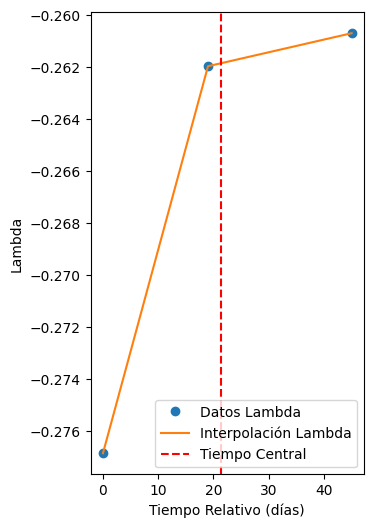

In [160]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_8, rho_8[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_8, np.polyval(poly_lambda_8, tiempo_relativo_8), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_8, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [161]:
#Para lambda

l_val_8 = np.polyval(poly_lambda_8, tiempo_central_reescalado_8)

derivada_1_l_8 = np.polyder(poly_lambda_8,1)
l_dval_8 = np.polyval(derivada_1_l_8, tiempo_central_reescalado_8)

derivada_2_l_8 = np.polyder(poly_lambda_8,2)
l_ddval_8 = np.polyval(derivada_2_l_8, tiempo_central_reescalado_8)

#Para mu

mu_val_8 = np.polyval(poly_mu_8, tiempo_central_reescalado_8)

derivada_1_mu_8 = np.polyder(poly_mu_8,1)
mu_dval_8 = np.polyval(derivada_1_mu_8, tiempo_central_reescalado_8)

derivada_2_mu_8 = np.polyder(poly_mu_8,2)
mu_ddval_8 = np.polyval(derivada_2_mu_8, tiempo_central_reescalado_8)

#Para nu

nu_val_8 = np.polyval(poly_nu_8, tiempo_central_reescalado_8)

derivada_1_nu_8 = np.polyder(poly_nu_8,1)
nu_dval_8 = np.polyval(derivada_1_nu_8, tiempo_central_reescalado_8)

derivada_2_nu_8 = np.polyder(poly_nu_8,2)
nu_ddval_8 = np.polyval(derivada_2_nu_8, tiempo_central_reescalado_8)

In [162]:
X_8= -9.448175510871250e-01
Y_8 = 2.999248903362722e-01
Z_8 = -1.264393001750415e-05

R_8 = np.sqrt(X_8**2 + Y_8**2 + Z_8**2)
print(R_8)

0.9912795492924111


In [163]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_8 = np.array([
    [l_val_8,  l_dval_8,  l_ddval_8],
    [mu_val_8, mu_dval_8, mu_ddval_8],
    [nu_val_8, nu_dval_8, nu_ddval_8]
])

# Calcular el determinante D
D_8 = np.linalg.det(matriz_D_8)
print(D_8)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_8 = np.array([
    [l_val_8, l_dval_8, X_8],
    [mu_val_8, mu_dval_8, Y_8],
    [nu_val_8, nu_dval_8, Z_8]
])

#Calcular el determiante D1
D1_8 = -k2* np.linalg.det(matriz_D1_8)
print(D1_8)

-1.1444822220808222e-09
-6.8413177777882445e-09


In [164]:
#Intento preliminar
intento_8 = D1_8/D_8 * (1/(0.99)**3 - 1/(5.2)**3)
intento_8

np.float64(6.118117143183229)

In [167]:
cos_phi_8 = (l_val_8*X_8 + mu_val_8*Y_8 +nu_val_8*Z_8)/(R_8)

# Bucle para hallar r y rho

r_obj_8 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_8 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_8 = (D1_8 / D_8) * (1/R_8**3 - 1/r_obj_8**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_8 = np.sqrt(rho_new_8**2 + R_8**2 + 2 * rho_new_8 * R_8 * cos_phi_8)
    
    print(f"{i:<5} | {rho_new_8:<15.8f} | {r_obj_8:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_8 - rho_old_8) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_8 = rho_new_8
    i += 1

rho_final_8 = rho_new_8
r_final_8 = r_obj_8

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_8:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_8:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 6.09429139      | 6.65995520     
1     | 6.11656866      | 6.68205121     
2     | 6.11676874      | 6.68224967     
3     | 6.11677052      | 6.68225144     
4     | 6.11677054      | 6.68225145     
5     | 6.11677054      | 6.68225145     
----------------------------------------
¡Convergencia lograda en 5 iteraciones!

Distancia Tierra-Júpiter (rho): 6.116771 UA
Distancia Sol-Júpiter (r): 6.682251 UA


In [168]:
#Finalmente, el vectoor de jupiter es

x_jup_8 = X_8 + rho_final_8 * l_val_8
y_jup_8 = Y_8 + rho_final_8 * mu_val_8
z_jup_8 = Z_8 + rho_final_8 * nu_val_8

vector_r_jupiter_8 = np.array([x_jup_8, y_jup_8, z_jup_8])
vector_r_jupiter_8

array([-2.54100377,  5.69930749,  2.39045843])

In [169]:
np.linalg.norm(vector_r_jupiter_8)

np.float64(6.682297323603285)

9na interpolacion: 28/02,11/03,26/03

In [170]:
tiempos_uso_jd_9 = [tiempos_dias_jd[1],tiempos_dias_jd[3],tiempos_dias_jd[5]]  
print(tiempos_uso_jd_9)

tiempo_central_9 = np.mean(tiempos_uso_jd_9)
print(tiempo_central_9)

#Construcción del vector rho

alpha_9 = [alpha[1],alpha[3],alpha[5]]
delta_9 = [delta[1],delta[3],delta[5]]

rho_9 = np.zeros((3, 3))

for i in range(3):
    rho_9[i, 0] = np.cos(delta_9[i]) * np.cos(alpha_9[i])  # x
    rho_9[i, 1] = np.cos(delta_9[i]) * np.sin(alpha_9[i])  # y
    rho_9[i, 2] = np.sin(delta_9[i])                     # z

[np.float64(2461100.509722222), np.float64(2461111.501388889), np.float64(2461126.504166667)]
2461112.8384259255


In [171]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c:

tiempo_relativo_9 = tiempos_uso_jd_9 - tiempos_uso_jd_9[0]

poly_lambda_9 = np.polyfit(tiempo_relativo_9, rho_9[:, 0], 2)
poly_mu_9 = np.polyfit(tiempo_relativo_9, rho_9[:, 1], 2)
poly_nu_9 = np.polyfit(tiempo_relativo_9, rho_9[:, 2], 2)

tiempo_central_reescalado_9 = tiempo_central_9 - tiempos_uso_jd_9[0] 

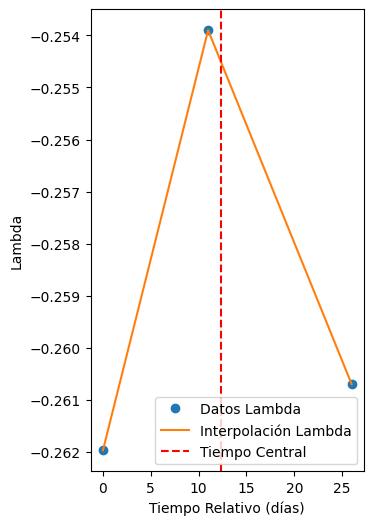

In [172]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_9, rho_9[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_9, np.polyval(poly_lambda_9, tiempo_relativo_9), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_9, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()

In [173]:
#Para lambda

l_val_9 = np.polyval(poly_lambda_9, tiempo_central_reescalado_9)

derivada_1_l_9 = np.polyder(poly_lambda_9,1)
l_dval_9 = np.polyval(derivada_1_l_9, tiempo_central_reescalado_9)

derivada_2_l_9 = np.polyder(poly_lambda_9,2)
l_ddval_9 = np.polyval(derivada_2_l_9, tiempo_central_reescalado_9)

#Para mu

mu_val_9 = np.polyval(poly_mu_9, tiempo_central_reescalado_9)

derivada_1_mu_9 = np.polyder(poly_mu_9,1)
mu_dval_9 = np.polyval(derivada_1_mu_9, tiempo_central_reescalado_9)

derivada_2_mu_9 = np.polyder(poly_mu_9,2)
mu_ddval_9 = np.polyval(derivada_2_mu_9, tiempo_central_reescalado_9)

#Para nu

nu_val_9 = np.polyval(poly_nu_9, tiempo_central_reescalado_9)

derivada_1_nu_9 = np.polyder(poly_nu_9,1)
nu_dval_9 = np.polyval(derivada_1_nu_9, tiempo_central_reescalado_9)

derivada_2_nu_9 = np.polyder(poly_nu_9,2)
nu_ddval_9 = np.polyval(derivada_2_nu_9, tiempo_central_reescalado_9)

In [174]:
X_9 = -9.851535867039268e-01
Y_9 = 1.316147881709701e-01
Z_9 = 1.573017050180500E-08

R_9 = np.sqrt(X_9**2 + Y_9**2 + Z_9**2)
print(R_9)

0.993906455286865


In [179]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_9 = np.array([
    [l_val_9,  l_dval_9,  l_ddval_9],
    [mu_val_9, mu_dval_9, mu_ddval_9],
    [nu_val_9, nu_dval_9, nu_ddval_9]
])

# Calcular el determinante D
D_9 = np.linalg.det(matriz_D_9)
print(D_9)

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_9 = np.array([
    [l_val_9, l_dval_9, X_9],
    [mu_val_9, mu_dval_9, Y_9],
    [nu_val_9, nu_dval_9, Z_9]
])

#Calcular el determiante D1
D1_9 = k2* np.linalg.det(matriz_D1_9)
print(D1_9)

-4.1852505673631724e-09
-3.730774106495592e-09


In [177]:
#Intento preliminar
intento_9 = D1_9/D_9 * (1/(0.99)**3 - 1/(5.2)**3)
intento_9

np.float64(0.9123564888713762)

In [180]:
cos_phi_9 = (l_val_9*X_9 + mu_val_9*Y_9 +nu_val_9*Z_9)/(R_9)

# Bucle para hallar r y rho

r_obj_9 = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_9 = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_9 = (D1_9 / D_9) * (1/R_9**3 - 1/r_obj_9**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_9 = np.sqrt(rho_new_9**2 + R_9**2 + 2 * rho_new_9 * R_9 * cos_phi_9)
    
    print(f"{i:<5} | {rho_new_9:<15.8f} | {r_obj_9:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_9 - rho_old_9) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_9 = rho_new_9
    i += 1

rho_final_9 = rho_new_9
r_final_9 = r_obj_9

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_9:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_9:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 0.90156646      | 1.56886044     
1     | 0.67705898      | 1.39369832     
2     | 0.57862174      | 1.32161125     
3     | 0.52174701      | 1.28156014     
4     | 0.48439922      | 1.25596628     
5     | 0.45797760      | 1.23822086     
6     | 0.43835474      | 1.22524407     
7     | 0.42327686      | 1.21539404     
8     | 0.41139822      | 1.20770999     
9     | 0.40186071      | 1.20158980     
10    | 0.39408877      | 1.19663563     
11    | 0.38768057      | 1.19257340     
12    | 0.38234635      | 1.18920771     
13    | 0.37787140      | 1.18639534     
14    | 0.37409309      | 1.18402874     
15    | 0.37088578      | 1.18202557     
16    | 0.36815089      | 1.18032164     
17    | 0.36580992      | 1.17886623     
18    | 0.36379965      | 1.17761869     
19    | 0.36206858      | 1.17654611     
20    | 0.36057440      | 1.17562158     
21    | 0.35928209      | 1.1748228

GENERAL

In [84]:
#Construcción del vector rho

rho_g = np.zeros((6, 3))

for i in range(6):
    rho_g[i, 0] = np.cos(delta[i]) * np.cos(alpha[i])  # x
    rho_g[i, 1] = np.cos(delta[i]) * np.sin(alpha[i])  # y
    rho_g[i, 2] = np.sin(delta[i])                     # z

In [85]:
tiempo_uso_jd = tiempos_dias_jd
tiempo_central_g = np.mean(tiempos_dias_jd)
tiempo_central_g

np.float64(2461107.0053240736)

In [125]:
#Interpolación de los componentes de rho (lambda, mu y nu)

#Como los dias julianos son muy grandes vamos a reescalar para ver si funciona bien c: Revisar

tiempo_relativo_g = tiempo_uso_jd - tiempo_uso_jd[0]

poly_lambda_g = np.polyfit(tiempo_relativo_g, rho_g[:, 0], 3)
poly_mu_g = np.polyfit(tiempo_relativo_g, rho_g[:, 1], 3)
poly_nu_g = np.polyfit(tiempo_relativo_g, rho_g[:, 2], 3)

tiempo_central_reescalado_g = tiempo_central_g - tiempo_uso_jd[0] 

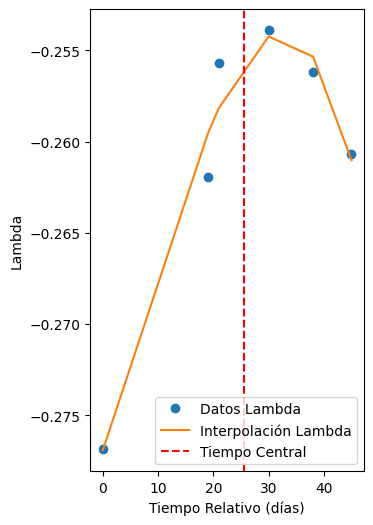

In [126]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(tiempo_relativo_g, rho_g[:, 0], 'o', label='Datos Lambda')
plt.plot(tiempo_relativo_g, np.polyval(poly_lambda_g, tiempo_relativo_g), '-', label='Interpolación Lambda')
plt.axvline(tiempo_central_reescalado_g, color='r', linestyle='--', label='Tiempo Central')
plt.xlabel('Tiempo Relativo (días)')
plt.ylabel('Lambda')
plt.legend()


In [127]:
#Para lambda

l_val_g = np.polyval(poly_lambda_g, tiempo_central_reescalado_g)

derivada_1_l_g = np.polyder(poly_lambda_g,1)
l_dval_g = np.polyval(derivada_1_l_g, tiempo_central_reescalado_g)

derivada_2_l_g = np.polyder(poly_lambda_g,2)
l_ddval_g = np.polyval(derivada_2_l_g, tiempo_central_reescalado_g)

#Para mu

mu_val_g = np.polyval(poly_mu_g, tiempo_central_reescalado_g)

derivada_1_mu_g = np.polyder(poly_mu_g,1)
mu_dval_g = np.polyval(derivada_1_mu_g, tiempo_central_reescalado_g)

derivada_2_mu_g = np.polyder(poly_mu_g,2)
mu_ddval_g = np.polyval(derivada_2_mu_g, tiempo_central_reescalado_g)

#Para nu

nu_val_g = np.polyval(poly_nu_g, tiempo_central_reescalado_g)

derivada_1_nu_g = np.polyder(poly_nu_g,1)
nu_dval_g = np.polyval(derivada_1_nu_g, tiempo_central_reescalado_g)

derivada_2_nu_g = np.polyder(poly_nu_g,2)
nu_ddval_g = np.polyval(derivada_2_nu_g, tiempo_central_reescalado_g)

In [128]:
X_g = -9.651731742053158e-01
Y_g = 2.306027893693601e-01
Z_g = -6.024262479168700e-06

R_g = np.sqrt(X_g**2 + Y_g**2 + Z_g**2)
R_g

np.float64(0.9923391067103957)

In [130]:
#Cálculo de las matrices D(rho) y D1(rho y R)

matriz_D_g = np.array([
    [l_val_g,  l_dval_g,  l_ddval_g],
    [mu_val_g, mu_dval_g, mu_ddval_g],
    [nu_val_g, nu_dval_g, nu_ddval_g]
])

# Calcular el determinante D
D_g = np.linalg.det(matriz_D_g)
print(D_g)

#D está dando 1.4240683042675966e-07. O los datos están muys eguidos entre sí, o estamos haciendo algo mal. Revisar.

#k es la constante de gravitación universal en unidades de UA^3/dia^{2}

k = 0.01720209895
k2 = k**2

matriz_D1_g = np.array([
    [l_val_g, l_dval_g, X_g],
    [mu_val_g, mu_dval_g, Y_g],
    [nu_val_g, nu_dval_g, Z_g]
])

#Calcular el determiante D1
D1_g = k2* np.linalg.det(matriz_D1_g)
print(D1_g)

1.4402620502345611e-09
3.239745510235792e-08


In [131]:
#Intento preliminar
intento_g = D1_g/D_g * (1/(0.99)**3 - 1/(5.2)**3)
intento_g

np.float64(23.022710602756717)

In [132]:
cos_phi_g = (l_val_g*X_g + mu_val_g*Y_g +nu_val_g*Z_g)/(R_g)

# Bucle para hallar r y rho

r_obj_g = 5.2  # Distancia promedio Sol Y Júpiter en UA
rho_old_g = 0
tolerancia = 1e-8
max_iter = 50
i = 0

print(f"{'Iter':<5} | {'rho (UA)':<15} | {'r (UA)':<15}")
print("-" * 40)

# Bucle
while i < max_iter:
    rho_new_g = (D1_g / D_g) * (1/R_g**3 - 1/r_obj_g**3)
    
    # Ley de los Cosenos: Hallamos el nuevo r a partir de rho
    # "El signo es positivo porque estamos asumiendo que R es desde el Sol hasta la Tierra"
    r_obj_g = np.sqrt(rho_new_g**2 + R_g**2 + 2 * rho_new_g * R_g * cos_phi_g)
    
    print(f"{i:<5} | {rho_new_g:<15.8f} | {r_obj_g:<15.8f}")
    
    # Para cuando rho ya no cambia
    if abs(rho_new_g - rho_old_g) < tolerancia:
        print("-" * 40)
        print(f"¡Convergencia lograda en {i} iteraciones!")
        break
        
    rho_old_g = rho_new_g
    i += 1

rho_final_g = rho_new_g
r_final_g = r_obj_g

print(f"\nDistancia Tierra-Júpiter (rho): {rho_final_g:.6f} UA")
print(f"Distancia Sol-Júpiter (r): {r_final_g:.6f} UA")

Iter  | rho (UA)        | r (UA)         
----------------------------------------
0     | 22.85916048     | 23.32656746    
1     | 23.01736593     | 23.48466000    
2     | 23.01740148     | 23.48469553    
3     | 23.01740148     | 23.48469553    
----------------------------------------
¡Convergencia lograda en 3 iteraciones!

Distancia Tierra-Júpiter (rho): 23.017401 UA
Distancia Sol-Júpiter (r): 23.484696 UA


In [133]:
#Finalmente, el vectoor de jupiter es

x_jup_g = X_g + rho_final_g * l_val_g
y_jup_g = Y_g + rho_final_g * mu_val_g
z_jup_g = Z_g + rho_final_g * nu_val_g

vector_r_jupiter_g = np.array([x_jup_g, y_jup_g, z_jup_g])
vector_r_jupiter_g

array([-6.84942478, 20.58352456,  8.99648165])

In [134]:
np.linalg.norm(vector_r_jupiter_g)

np.float64(23.484735154906154)

In [184]:
media_distancia = np.mean([5.343803, 6.451000, 4.049688, 6.682251])
print(media_distancia)

media_distancia_tj = np.mean([4.720881, 5.823407, 3.460185, 6.116771])
print(media_distancia_tj)

5.6316855
5.030311


In [186]:
media_distancias_todas = np.mean([rho_final,rho_final_2,rho_final_3,rho_final_4,rho_final_5,rho_final_6,rho_final_7,rho_final_8,rho_final_9,rho_final_g])
print(media_distancias_todas)

media_distancias_solares = np.mean([r_final,r_final_2,r_final_3,r_final_4,r_final_5,r_final_6,r_final_7,r_final_8,r_final_9,r_final_g])
print(media_distancias_solares)

5.427186433243937
6.069778906197608


Quitando los datos extremos de 0 UA

In [187]:
media_distancias_todas = np.mean([rho_final,rho_final_2,rho_final_3,rho_final_4,rho_final_5,rho_final_7,rho_final_8])
print(media_distancias_todas)

media_distancias_solares = np.mean([r_final,r_final_2,r_final_3,r_final_4,r_final_5,r_final_7,r_final_8])
print(media_distancias_solares)

4.412291937572883
5.006153426117764
